## Intensity Distributions
___
Per-cell and pooled intensity distribution analysis.

In [1]:
import sys
from pathlib import Path
from microlive import microscopy as mi
one_drive_dir = mi.Utilities.get_one_drive_dir()
repo_root = Path().resolve().parents[1]  
sys.path.insert(0, str(repo_root))
import utilities 
from utilities import intensity_distributions as idist


## Data path & folder detection
___

In [2]:
#dataframes_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Zhao lab shared folder' / 'Our papers' / 'co-translational folding paper' / 'Fig 1' / 'Fig 1_Trunc minitrack analysis'
dataframes_dir = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/co-translational folding paper/Fig 2/Fig 2_4xGFP coTFT minitrack analysis')

#dataframes_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Zhao lab shared folder' / 'Our papers' / 'co-translational folding paper' / 'Fig 2' / 'Fig 2_4xGFP coTFT minitrack analysis'


In [3]:
current_dir = Path().resolve()
save_dir = current_dir / f'results_{dataframes_dir.name}'
save_dir.mkdir(parents=True, exist_ok=True)
print('Plots saved at:', save_dir)
list_folder_substrings, list_names = utilities.get_folder_substrings_and_names(dataframes_dir)
print('Substrings:', list_folder_substrings)
print('Names:', list_names)


Plots saved at: /Users/nzlab-la/Desktop/cof_paper/notebooks/CoF_project/results_Fig 2_4xGFP coTFT minitrack analysis
Found 2 plasmids in 23 folders
  pRS027: 1 experiment(s)
  pRS032: 1 experiment(s)
Substrings: ['pRS027', 'pRS032']
Names: ['4sfGFP-2mCh', '4GFPuv-2mCh']


## Parameters
___

In [4]:
# ── Data & filtering ──────────────────────────────────────────────────────────
selected_field        = 'spot_int_ch_'   # column prefix
drop_nonpositive      = True            # False → keep negatives; True → drop ≤ 0

# ── Display mode ──────────────────────────────────────────────────────────────
# Mode 1: "mean per particle" — time-averaged intensity per particle (1 value
#         per particle). Removes frame-to-frame noise.
# Mode 2: "all timepoints" — every (particle × frame) measurement as an
#         independent sample. Preserves temporal fluctuations.
display_mode          = 1                # 1 = mean per particle | 2 = all timepoints

# ── Visualization toggles ────────────────────────────────────────────────────
show_individual_cells = False            # per-cell subplot grids
show_hist             = True             # density histogram behind KDE (pooled)
show_cell_summary     = False             # swarm + box plot (one point per cell)
cell_stat             = 'median'           # 'mean' or 'median' per cell

# ── X-axis limits ─────────────────────────────────────────────────────────────
xlim_override         = None             # e.g. (-10, 1500) or None for auto
xlim_percentile_lo    = 0.5                # lower percentile (auto mode)
xlim_percentile_hi    = 99.5               # upper percentile (auto mode)

# ── KDE configuration ─────────────────────────────────────────────────────────
kde_bw_method         = 'scott'          # 'scott', 'silverman', or a float
kde_alpha             = 0.3              # fill alpha for overlapping distributions

# ── Figure sizes & colours ────────────────────────────────────────────────────
figsize_distributions = (4, 5)           # pooled KDE overlay
figsize_whisker       = (4, 5)           # cell-level swarm + box
list_colors           = ['gray', 'tab:orange']


# coloc_filter 
#coloc_filter=None #— all trajectories
coloc_filter='colocalized'
#coloc_filter='not_colocalized'



## Per-cell & pooled distribution plots
___


══════ Channel 1 (Nascent Chain) ══════
  4sfGFP-2mCh                     mean=843.27   median=711.10   std=533.90   n=1994   n_cells=12
  4GFPuv-2mCh                     mean=750.84   median=595.77   std=534.42   n=404   n_cells=11
  Kolmogorov-Smirnov test (pooled): D=0.1403, p=3.106e-06
    D statistic: max distance between the two CDFs (0 = identical, 1 = completely separated)
    p-value: probability of observing D this large if the distributions were truly identical


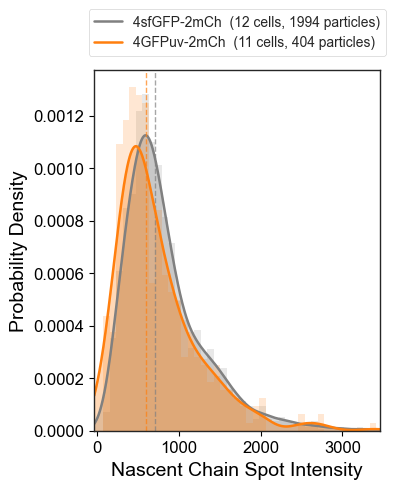


══════ Channel 0 (Folding) ══════
  4sfGFP-2mCh                     mean=614.78   median=522.79   std=406.77   n=1994   n_cells=12
  4GFPuv-2mCh                     mean=549.91   median=447.60   std=497.51   n=404   n_cells=11
  Kolmogorov-Smirnov test (pooled): D=0.1181, p=0.000153
    D statistic: max distance between the two CDFs (0 = identical, 1 = completely separated)
    p-value: probability of observing D this large if the distributions were truly identical


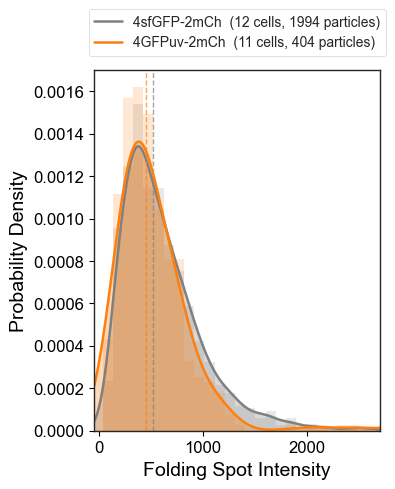

In [5]:
xlim_pcts = (xlim_percentile_lo, xlim_percentile_hi)
for ch, ch_label in [(1, "Nascent Chain"), (0, "Folding")]:
    print(f"\n══════ Channel {ch} ({ch_label}) ══════")

    # Load data for this channel
    all_results_ch = []
    for folder_sub, name in zip(list_folder_substrings, list_names):
        r = idist.load_condition_intensities(dataframes_dir, folder_sub,selected_field=selected_field,channel_index=ch,drop_nonpositive=drop_nonpositive,coloc_filter=coloc_filter)
        r["name"] = name
        all_results_ch.append(r)

    # Per-cell panels
    if show_individual_cells:
        for result, color in zip(all_results_ch, list_colors):
            idist.plot_per_cell_distributions(result, color=color, save_dir=save_dir,channel_index=ch, mode=display_mode,xlim=xlim_override, xlim_percentiles=xlim_pcts,
            kde_bw_method=kde_bw_method, kde_alpha=kde_alpha,drop_nonpositive=drop_nonpositive)
    # Cell-level summary (one point per cell, avoids pseudoreplication)
    if show_cell_summary:
        idist.plot_cell_summary(all_results_ch, list_colors, channel_index=ch,save_dir=save_dir, mode=display_mode,cell_stat=cell_stat,drop_nonpositive=drop_nonpositive,figsize=figsize_whisker, )

    # Pooled overlay
    idist.plot_pooled_distributions(all_results_ch, list_colors, channel_index=ch,x_label=f"{ch_label} Spot Intensity",
        save_dir=save_dir, mode=display_mode, xlim=xlim_override, xlim_percentiles=xlim_pcts, kde_bw_method=kde_bw_method, kde_alpha=kde_alpha,
        show_hist=show_hist,drop_nonpositive=drop_nonpositive,figsize=figsize_distributions,  )


  4sfGFP-2mCh Total               mean=530.26   median=427.76   std=405.66   n=2497   n_cells=12
  4sfGFP-2mCh Coloc               mean=614.78   median=522.79   std=406.77   n=1994   n_cells=12
  4sfGFP-2mCh Not Coloc           mean=195.23   median=153.74   std=142.91   n=503   n_cells=12
  4GFPuv-2mCh Total               mean=380.48   median=307.43   std=354.36   n=1311   n_cells=11
  4GFPuv-2mCh Coloc               mean=549.91   median=447.60   std=497.51   n=404   n_cells=11
  4GFPuv-2mCh Not Coloc           mean=305.01   median=254.53   std=229.70   n=907   n_cells=11


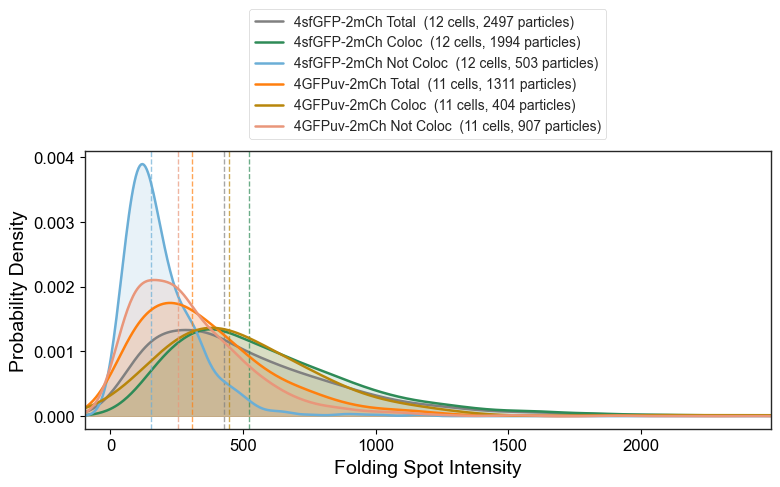

In [6]:
ch = 0  # Folding channel
ch_label = "Folding"

# Load 3 sub-populations for each condition
all_results_overlay = []
overlay_colors = []

# Color palette: condition 1 (cool tones), condition 2 (warm tones)
color_map = {
    0: {"Total": "gray",       "Coloc": "#2e8b57",  "Not Coloc": "#6baed6"},
    1: {"Total": "tab:orange", "Coloc": "#b8860b",  "Not Coloc": "#e9967a"},
}

filters = [
    (None,              "Total"),
    ("colocalized",     "Coloc"),
    ("not_colocalized", "Not Coloc"),
]

for cond_idx, (folder_sub, name) in enumerate(zip(list_folder_substrings, list_names)):
    for coloc_val, label_suffix in filters:
        r = idist.load_condition_intensities(
            dataframes_dir, folder_sub,
            selected_field=selected_field,
            channel_index=ch,
            drop_nonpositive=drop_nonpositive,
            coloc_filter=coloc_val,
            verbose=False,
        )
        r["name"] = f"{name} {label_suffix}"
        all_results_overlay.append(r)
        overlay_colors.append(color_map[cond_idx][label_suffix])


# ── Plot all 6 overlaid ──────────────────────────────────────────────────────
xlim_pcts = (xlim_percentile_lo, xlim_percentile_hi)

idist.plot_pooled_distributions(
    all_results_overlay,
    overlay_colors,
    channel_index=ch,
    x_label=f"{ch_label} Spot Intensity",
    save_dir=save_dir,
    mode=display_mode,
    xlim=xlim_override,
    xlim_percentiles=xlim_pcts,
    kde_bw_method=kde_bw_method,
    kde_alpha=0.15,            
    show_hist=False,           
    drop_nonpositive=drop_nonpositive,
    figsize=(8, 5),            # wider figure for 6 legends
)
